In [1]:
import scipp as sc
import plopp as pp
import scippneutron as scn
import scippnexus as snx
import h5py

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [3]:
incoherent_elastic_datafile = "20240829/BIFROST_20240829T192305.h5"
coherent_inelastic_datafile = "20240914/BIFROST_20240914T053723.h5"

In [4]:
from bifrost2409.config import POOCH_DATA_DIR
from bifrost2409.dataset import download_datafiles
download_datafiles([incoherent_elastic_datafile, coherent_inelastic_datafile])

2024-10-21 11:12:06.249 | INFO     | bifrost2409.config:<module>:13 - PROJ_ROOT path is: /home/g/Projects/20240914/bifrost-workflow-2409
Fetching: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00,  3.98it/s]


In [7]:
from ess.spectroscopy.indirect import bifrost_single, bifrost
sim_bifrost_single = lambda x: bifrost_single(POOCH_DATA_DIR / x, is_simulated=True)
sim_bifrost = lambda x: bifrost(POOCH_DATA_DIR / x, is_simulated=True)

In [8]:
incoherent_elastic = sim_bifrost_single(incoherent_elastic_datafile)

In [10]:
list(incoherent_elastic)

['triplet_events',
 'events',
 'norm_monitor',
 'sample_detector_flight_time',
 'analyzers',
 'wavelength_monitor',
 'norm_events']

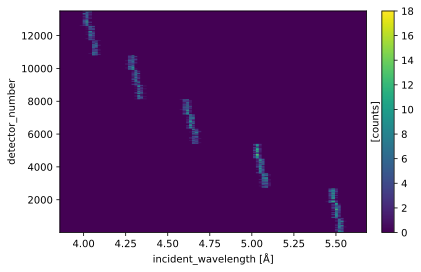

In [13]:
incoherent_elastic['norm_events'].hist().plot()

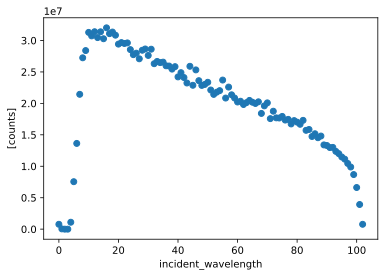

In [20]:
incoherent_elastic['norm_events'].coords['monitor'].plot()

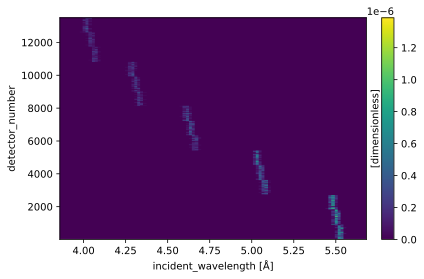

In [21]:
norm_to = incoherent_elastic['norm_events'].coords['monitor']
norm_to.variances = None
normalized = incoherent_elastic['norm_events'] / norm_to
normalized.hist().plot()

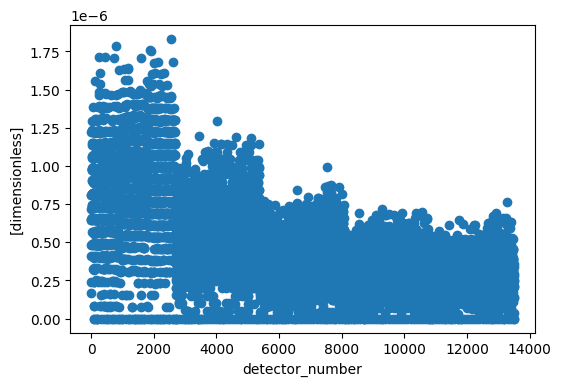

In [23]:
normalized.sum('incident_wavelength').plot()

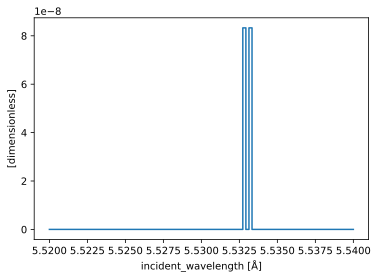

In [35]:
normalized['detector_number', 0].hist(incident_wavelength=sc.linspace(start=5.52,stop=5.54,unit='angstrom',num=100,dim='incident_wavelength')).plot()

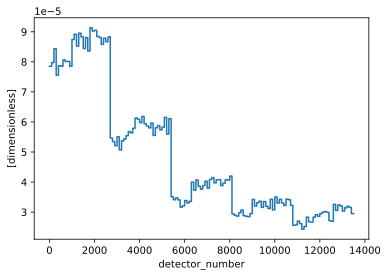

In [43]:
tubes = normalized.bin(detector_number=sc.arange(start=0,stop=13500+1,step=100,unit=None,dim='detector_number'))
tubes.sum('incident_wavelength').plot()

In [46]:
tubes['detector_number',0].hist(incident_wavelength=sc.linspace(start=5.0,stop=6.0,unit='angstrom',num=100,dim='incident_wavelength'))

<scipp.DataArray>
Dimensions: Sizes[incident_wavelength:99, ]
Coordinates:
  detector_number             int64        <no unit>  (detector_number [bin-edge])  [0, 100]
* incident_wavelength       float64             [Å]  (incident_wavelength [bin-edge])  [5, 5.0101, ..., 5.9899, 6]
Data:
                            float64  [dimensionless]  (incident_wavelength)  [0, 0, ..., 0, 0]

In [ ]:
def auto_fit(data_array, dim):
    y = data_array.data
    y_norm = y.sum(dim)
    x = data_array.coords[dim]
    xc = sc.midpoints(x) if x.sizes[dim] == y.sizes[dim] + 1 else x
    center_of_mass = (xc * y) / y.sizes[dim] / y_norm
    first_moment = (xc - center_of_mass) * y / y_norm
    second_moment = (xc - center_of_mass) ** 2 * y /y_norm